In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1787409555.500463    5395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787409555.501148    5395 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787409555.582049    5395 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787409556.778908    5395 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787409556.779310    5395 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [ ]:
df = pd.read_csv('bengaluru_house_prices.csv')
print("Shape:", df.shape)
df.head()


Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [ ]:
df.describe()


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [ ]:
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

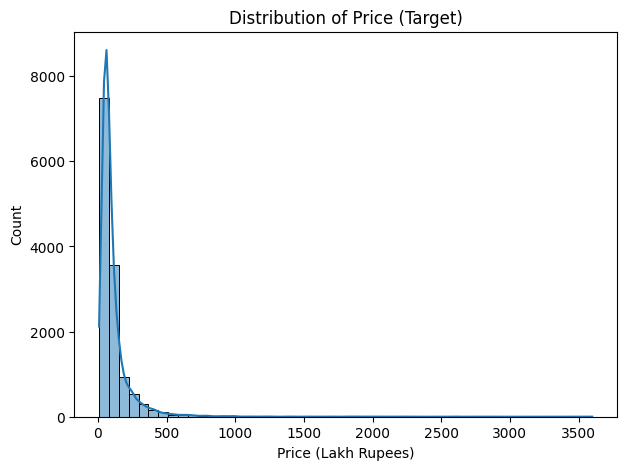

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price (Target)')
plt.xlabel('Price (Lakh Rupees)')
plt.show()


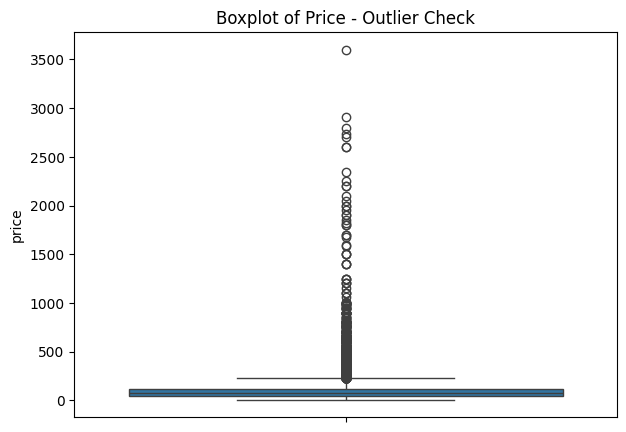

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(y=df['price'])
plt.title('Boxplot of Price - Outlier Check')
plt.show()


In [ ]:
df = df.drop(columns=['society'])

df['bhk'] = df['size'].str.split(' ').str[0]
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')

def convert_sqft(x):
    tokens = str(x).split(' - ')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None 

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df[['size', 'bhk', 'total_sqft']].head(10)


,size,bhk,total_sqft
0,2 BHK,2.0,1056.0
1,4 Bedroom,4.0,2600.0
2,3 BHK,3.0,1440.0
3,3 BHK,3.0,1521.0
4,2 BHK,2.0,1200.0
5,2 BHK,2.0,1170.0
6,4 BHK,4.0,2732.0
7,4 BHK,4.0,3300.0
8,3 BHK,3.0,1310.0
9,6 Bedroom,6.0,1020.0


In [ ]:
df = df.dropna(subset=['location', 'size', 'total_sqft', 'bhk']).copy()

df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

print(df.isnull().sum())
print("Shape after cleaning:", df.shape)


area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
dtype: int64
Shape after cleaning: (13257, 9)


In [ ]:
df['ready_to_move'] = (df['availability'] == 'Ready To Move').astype(int)
df = df.drop(columns=['availability'])

df['location'] = df['location'].apply(lambda x: x.strip())
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10]
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

print("Unique locations after grouping:", df['location'].nunique())


Unique locations after grouping: 241


In [ ]:
df = df[~(df['total_sqft'] / df['bhk'] < 300)]
print("Shape after removing unrealistic sqft/bhk rows:", df.shape)


Shape after removing unrealistic sqft/bhk rows: (12513, 9)


In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print("Shape before:", df.shape, "| after removing price outliers:", df_clean.shape)


Shape before: (12513, 9) | after removing price outliers: (11235, 9)


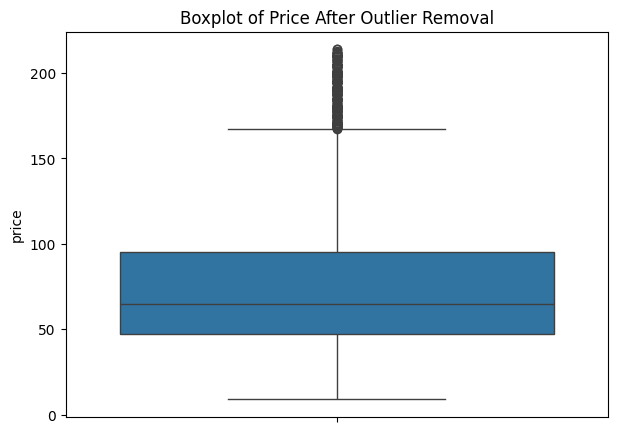

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(y=df_clean['price'])
plt.title('Boxplot of Price After Outlier Removal')
plt.show()


In [ ]:
df_model = pd.get_dummies(df_clean, columns=['area_type', 'location'], drop_first=True)

df_model = df_model.drop(columns=['size'])

print("Final shape:", df_model.shape)
df_model.head()


Final shape: (11235, 248)


,total_sqft,bath,balcony,price,bhk,ready_to_move,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,39.07,2.0,0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4.0,1,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3.0,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2.0,1,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X = df_model.drop(columns=['price'])
y = df_model['price']

print("Features:", X.shape[1])
print("X shape:", X.shape, "| y shape:", y.shape)


Features: 247
X shape: (11235, 247) | y shape: (11235,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (8988, 247) | Test shape: (2247, 247)


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
def build_model_1(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_1 = build_model_1(X_train_scaled.shape[1])
model_1.summary()


E0000 00:00:1787409557.868498    5395 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_1 = model_1.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    verbose=0
)
print("Done training Model 1")


Done training Model 1


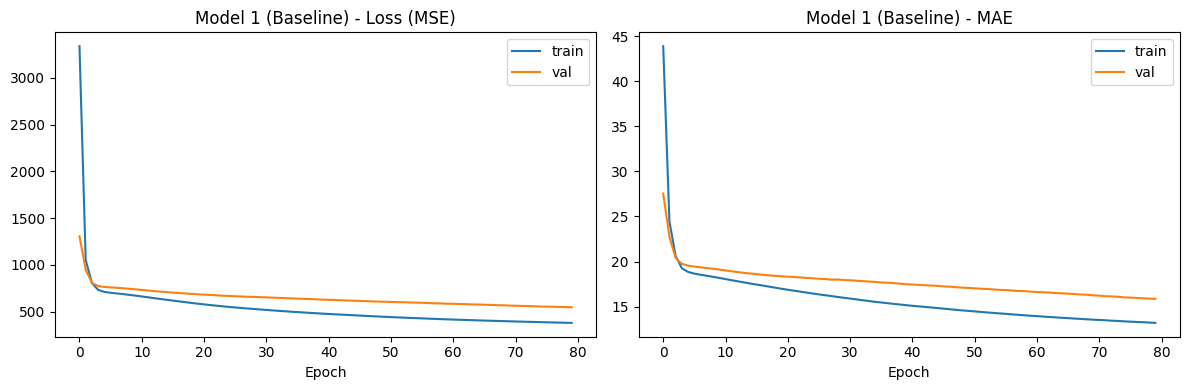

In [ ]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{title} - Loss (MSE)')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['mae'], label='train')
    axes[1].plot(history.history['val_mae'], label='val')
    axes[1].set_title(f'{title} - MAE')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_1, 'Model 1 (Baseline)')


--- Model 1 (Baseline) ---
MSE  : 560.08
RMSE : 23.67
MAE  : 16.19
R2   : 0.6556


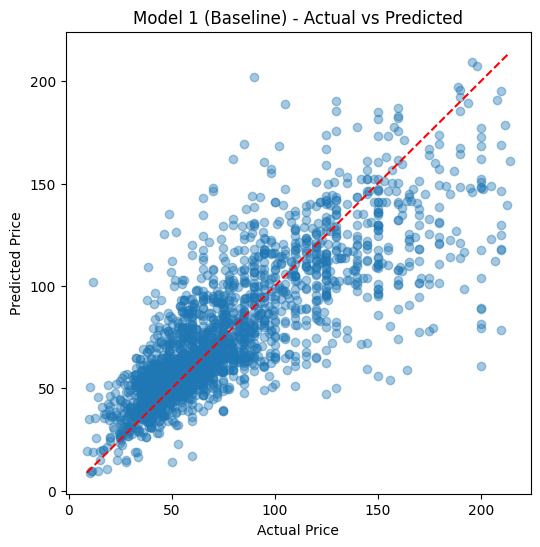

In [ ]:
def evaluate_model(model, X_test, y_test, name='Model'):
    y_pred = model.predict(X_test, verbose=0).ravel()

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"--- {name} ---")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"R2   : {r2:.4f}")

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.4)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{name} - Actual vs Predicted')
    plt.show()

    return {'model': name, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

results = []
results.append(evaluate_model(model_1, X_test_scaled, y_test, 'Model 1 (Baseline)'))


In [ ]:
def build_model_2(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model_2 = build_model_2(X_train_scaled.shape[1])
model_2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        31,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 42,113 (164.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)
print(f"Stopped at epoch: {len(history_2.history['loss'])}")


Stopped at epoch: 150


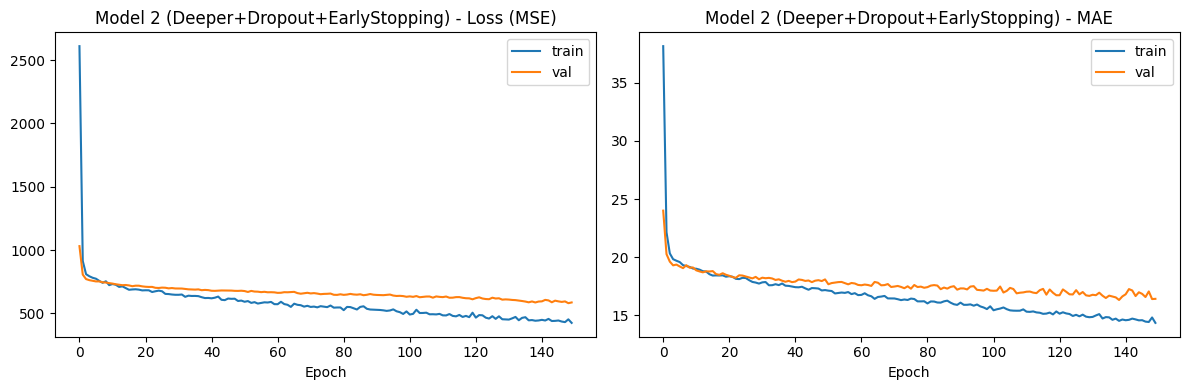

In [ ]:
plot_history(history_2, 'Model 2 (Deeper+Dropout+EarlyStopping)')


--- Model 2 (Deeper+Dropout) ---
MSE  : 556.76
RMSE : 23.60
MAE  : 16.21
R2   : 0.6577


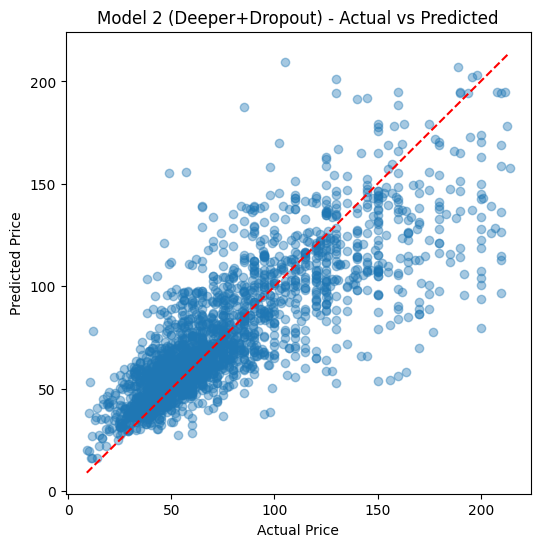

In [ ]:
results.append(evaluate_model(model_2, X_test_scaled, y_test, 'Model 2 (Deeper+Dropout)'))


In [ ]:
def build_model_3(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='mse',
        metrics=['mae']
    )
    return model

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5
)

model_3 = build_model_3(X_train_scaled.shape[1])

history_3 = model_3.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f"Stopped at epoch: {len(history_3.history['loss'])}")


Stopped at epoch: 23


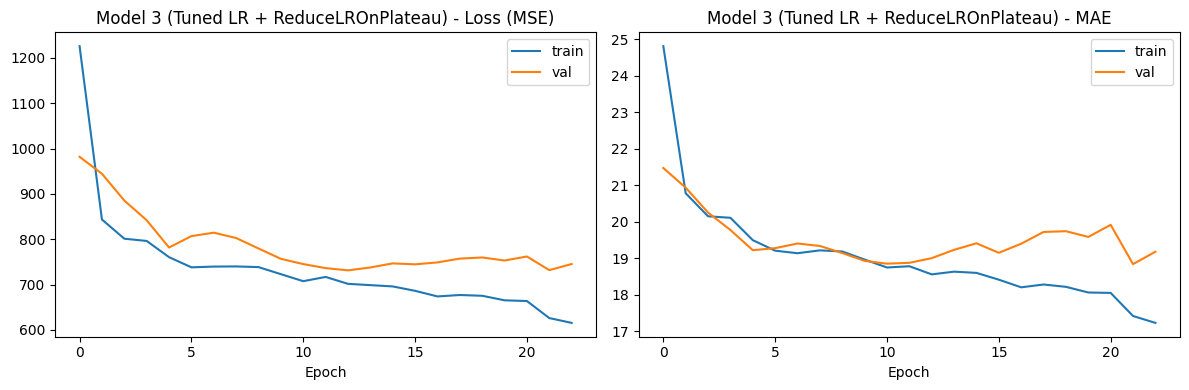

In [ ]:
plot_history(history_3, 'Model 3 (Tuned LR + ReduceLROnPlateau)')


--- Model 3 (TunedLR+ReduceLR) ---
MSE  : 742.67
RMSE : 27.25
MAE  : 19.27
R2   : 0.5433


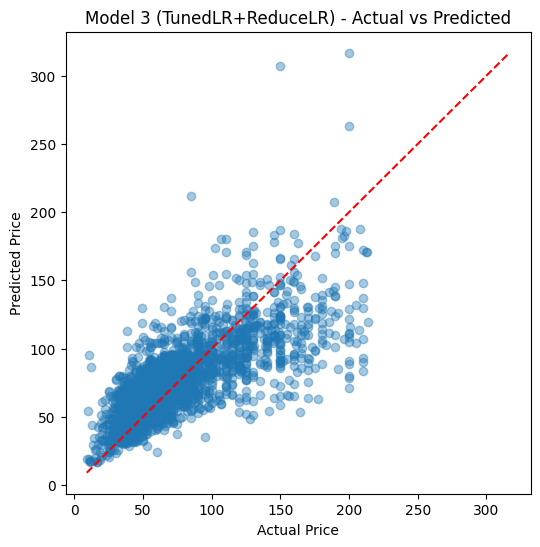

In [ ]:
results.append(evaluate_model(model_3, X_test_scaled, y_test, 'Model 3 (TunedLR+ReduceLR)'))


In [ ]:
results_df = pd.DataFrame(results).set_index('model')
results_df.round(4)


,mse,rmse,mae,r2
model,,,,
Model 1 (Baseline),560.0791,23.6660,16.1897,0.6556
Model 2 (Deeper+Dropout),556.7618,23.5958,16.2092,0.6577
Model 3 (TunedLR+ReduceLR),742.6739,27.2520,19.2734,0.5433


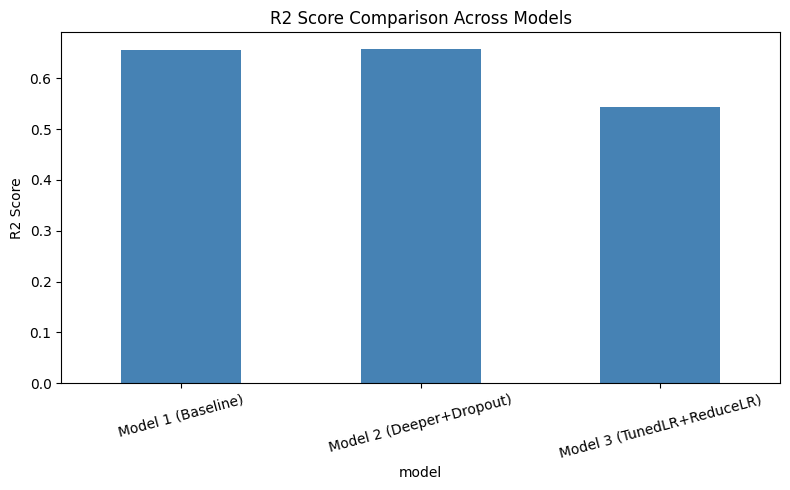

In [ ]:
results_df[['r2']].plot(kind='bar', figsize=(8,5), legend=False, color='steelblue')
plt.title('R2 Score Comparison Across Models')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
